In [1]:
import numpy as np
import matplotlib.pyplot as plt


# =========================================================
# Function
# =========================================================

def f(x):
    return 1 / (1 + x**2)


# =========================================================
# Newton interpolation
# =========================================================

def divided_difference_table(x, y):

    n = len(x)

    table = np.zeros((n, n))

    table[:, 0] = y

    for j in range(1, n):
        for i in range(n - j):

            table[i, j] = (
                table[i + 1, j - 1]
                - table[i, j - 1]
            ) / (x[i + j] - x[i])

    return table


def newton_coefficients(table):

    return table[0, :]


def newton_interpolation(x_data, coefficients, x):

    n = len(coefficients)

    result = coefficients[n - 1]

    for i in range(n - 2, -1, -1):

        result = coefficients[i] + (
            x - x_data[i]
        ) * result

    return result



In [2]:
def f(x):
    return 1 / (1 + 25*x**2)

In [4]:
n = 4
x_data = -1 + 2 * np.arange(n + 1) / n

In [5]:
x_data

array([-1. , -0.5,  0. ,  0.5,  1. ])

In [6]:
x_eval = np.linspace(-1, 1, 500)

In [7]:
exact_values = f(x_eval)

Newton Interpolation Error Analysis
------------------------------------
Degree	Points	Maximum Error	Location
4	5	4.3835144567e-01	-0.795591
8	9	1.0451657689e+00	-0.919840
12	13	3.6628680036e+00	-0.951904
16	17	1.4387236564e+01	0.967936
20	21	5.9771050535e+01	-0.975952


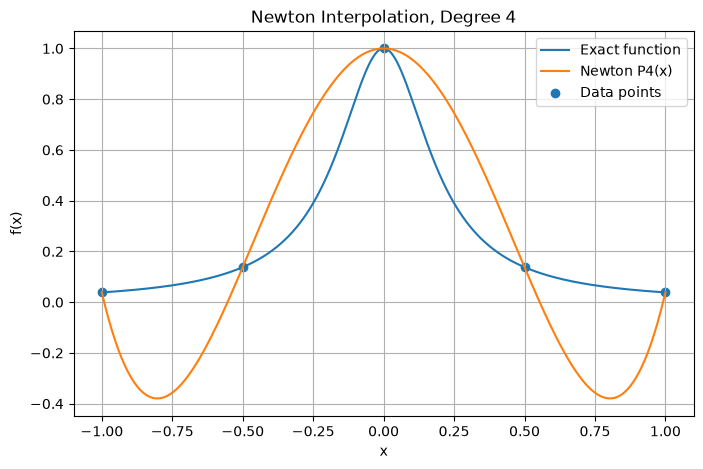

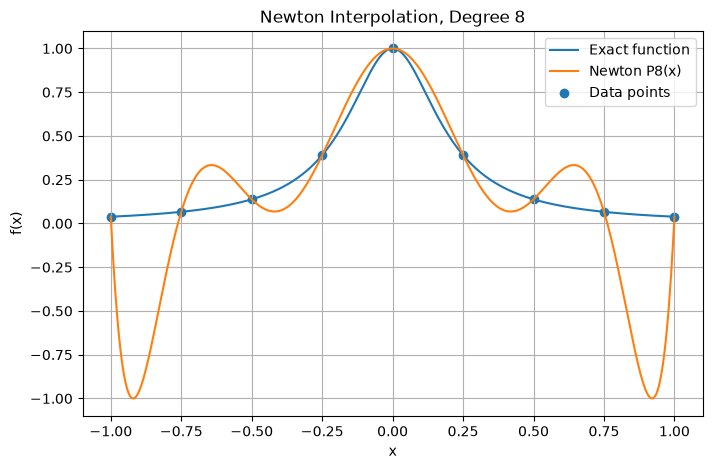

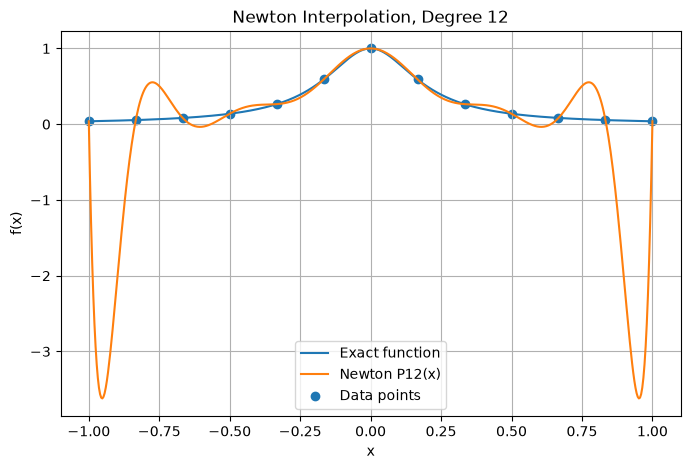

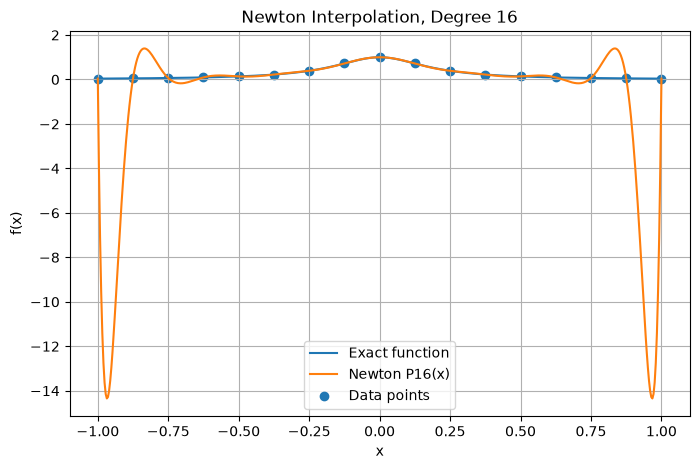

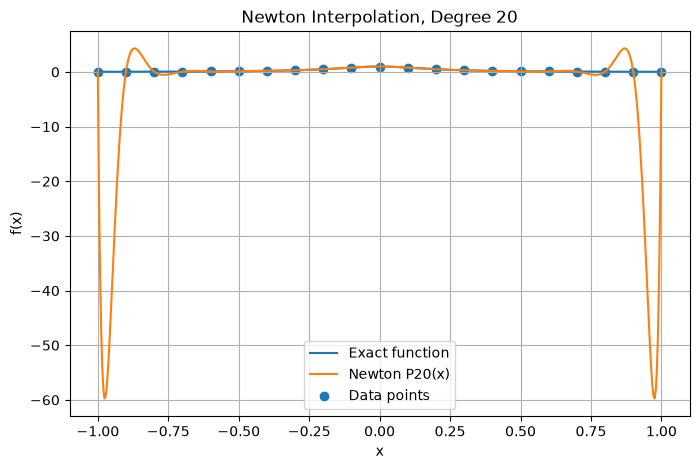

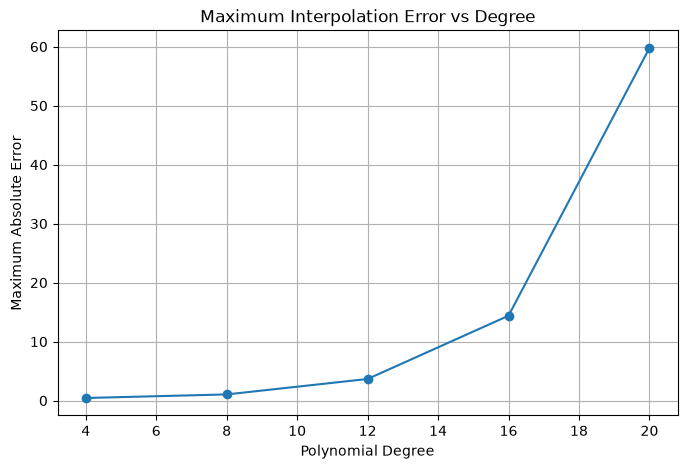

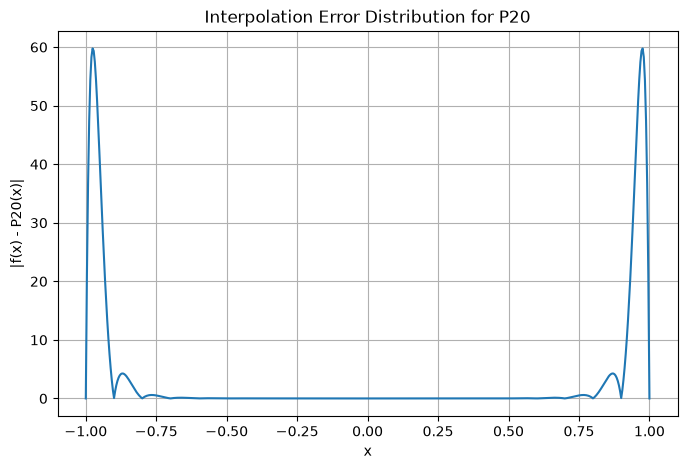

In [8]:
import numpy as np
import matplotlib.pyplot as plt


# =========================================================
# Function
# =========================================================

def f(x):
    return 1 / (1 + 25*x**2)


# =========================================================
# Newton divided-difference table
# =========================================================

def divided_difference_table(x, y):

    n = len(x)

    table = np.zeros((n, n))

    # Zeroth-order divided differences
    table[:, 0] = y

    # Higher-order divided differences
    for j in range(1, n):
        for i in range(n - j):

            table[i, j] = (
                table[i + 1, j - 1]
                - table[i, j - 1]
            ) / (x[i + j] - x[i])

    return table


# =========================================================
# Newton coefficients
# =========================================================

def newton_coefficients(table):

    return table[0, :]


# =========================================================
# Newton polynomial evaluation
# =========================================================

def newton_interpolation(x_data, coefficients, x):

    n = len(coefficients)

    result = coefficients[n - 1]

    for i in range(n - 2, -1, -1):

        result = coefficients[i] + (
            x - x_data[i]
        ) * result

    return result


# =========================================================
# Q5
# =========================================================

degrees = [4, 8, 12, 16, 20]

# 500 evaluation points
x_eval = np.linspace(-1, 1, 500)

# Exact function
exact_values = f(x_eval)


# Store results
maximum_errors = []
error_locations = []

interpolations = {}
errors = {}


# =========================================================
# Construct interpolation for each degree
# =========================================================

for n in degrees:

    # Generate n+1 equally spaced points
    x_data = -1 + 2 * np.arange(n + 1) / n

    # Function values at interpolation points
    y_data = f(x_data)

    # Construct divided-difference table
    table = divided_difference_table(
        x_data,
        y_data
    )

    # Extract Newton coefficients
    coefficients = newton_coefficients(table)

    # Evaluate interpolation polynomial
    p_values = np.array([
        newton_interpolation(
            x_data,
            coefficients,
            point
        )
        for point in x_eval
    ])

    # Calculate absolute error
    error = np.abs(
        exact_values - p_values
    )

    # Maximum error
    max_index = np.argmax(error)

    max_error = error[max_index]

    max_error_x = x_eval[max_index]

    # Store results
    maximum_errors.append(max_error)

    error_locations.append(max_error_x)

    interpolations[n] = p_values

    errors[n] = error


# =========================================================
# Print results
# =========================================================

print("Newton Interpolation Error Analysis")
print("------------------------------------")

print(
    "Degree\tPoints\tMaximum Error\tLocation"
)

for n, max_error, location in zip(
    degrees,
    maximum_errors,
    error_locations
):

    print(
        f"{n}\t"
        f"{n+1}\t"
        f"{max_error:.10e}\t"
        f"{location:.6f}"
    )


# =========================================================
# Plot 1: Exact function and interpolations
# =========================================================

for n in degrees:

    plt.figure(figsize=(8, 5))

    plt.plot(
        x_eval,
        exact_values,
        label="Exact function"
    )

    plt.plot(
        x_eval,
        interpolations[n],
        label=f"Newton P{n}(x)"
    )

    x_data = -1 + 2 * np.arange(n + 1) / n

    y_data = f(x_data)

    plt.scatter(
        x_data,
        y_data,
        label="Data points"
    )

    plt.xlabel("x")
    plt.ylabel("f(x)")

    plt.title(
        f"Newton Interpolation, Degree {n}"
    )

    plt.legend()
    plt.grid(True)

    plt.show()


# =========================================================
# Plot 2: Maximum error vs degree
# =========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    degrees,
    maximum_errors,
    marker="o"
)

plt.xlabel("Polynomial Degree")

plt.ylabel("Maximum Absolute Error")

plt.title(
    "Maximum Interpolation Error vs Degree"
)

plt.grid(True)

plt.show()


# =========================================================
# Plot 3: Error distribution for n = 20
# =========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    x_eval,
    errors[20]
)

plt.xlabel("x")

plt.ylabel(
    "|f(x) - P20(x)|"
)

plt.title(
    "Interpolation Error Distribution for P20"
)

plt.grid(True)

plt.show()